In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load data
df = pd.read_csv('diabetic_data.csv')
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Check for missing values and data types
print(df.info())
print("\nMissing/unknown values:")
print((df == '?').sum()[df.eq('?').sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop columns with too many missing values
df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)

# Drop rows with remaining nulls
df.dropna(inplace=True)

# Create binary target variable: 1 if readmitted early (<30 days), 0 otherwise
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print("Cleaned dataset shape:", df.shape)
print("\nReadmission distribution:")
print(df['readmitted_binary'].value_counts())

Cleaned dataset shape: (289, 48)

Readmission distribution:
readmitted_binary
0    254
1     35
Name: count, dtype: int64


In [5]:
# Reload the data fresh
df = pd.read_csv('diabetic_data.csv')

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop columns with too many missing values (>40% missing)
threshold = len(df) * 0.6
df.dropna(thresh=threshold, axis=1, inplace=True)

# Fill remaining nulls with 'Unknown'
df.fillna('Unknown', inplace=True)

# Create binary target: 1 if readmitted early (<30 days), 0 otherwise
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print("Cleaned dataset shape:", df.shape)
print("\nReadmission distribution:")
print(df['readmitted_binary'].value_counts())

Cleaned dataset shape: (101766, 47)

Readmission distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64


In [6]:
# Select features for the model
features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
            'num_medications', 'number_outpatient', 'number_emergency', 
            'number_inpatient', 'age', 'admission_type_id', 
            'discharge_disposition_id', 'admission_source_id']

X = df[features].copy()
y = df['readmitted_binary']

# Encode age (it's a range like [0-10])
le = LabelEncoder()
X['age'] = le.fit_transform(X['age'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (81412, 11)
Test set size: (20354, 11)


In [7]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Evaluate
y_pred = lr_model.predict(X_test)
print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.49      0.01      0.03      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.48     20354
weighted avg       0.84      0.89      0.84     20354

ROC-AUC Score: 0.6433324973720059


In [8]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest with class balancing
rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.31      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.60      0.51      0.49     20354
weighted avg       0.82      0.89      0.84     20354

ROC-AUC Score: 0.6307397371380118


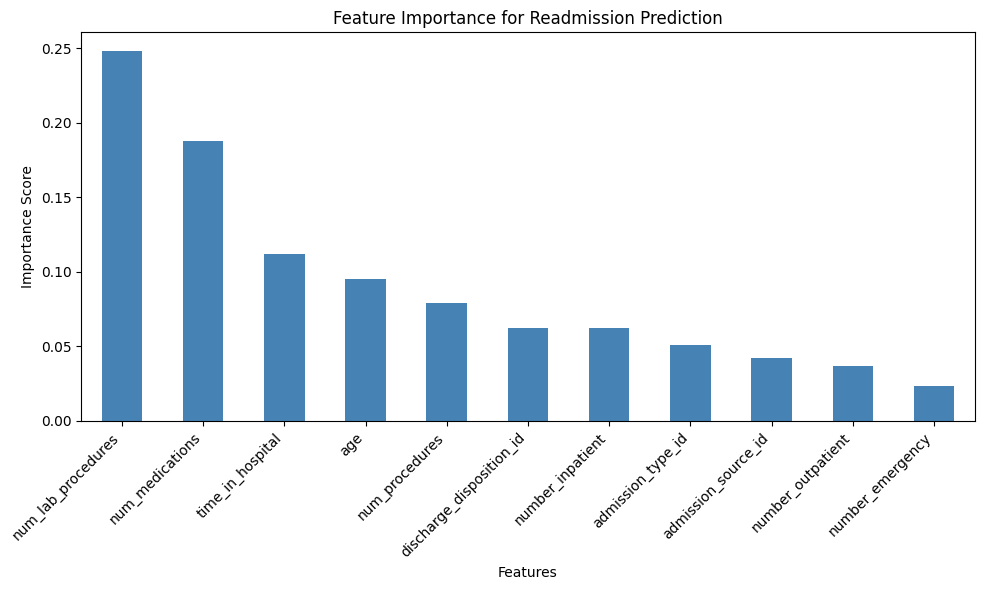

In [9]:
# Feature importance chart
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_, index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance for Readmission Prediction')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

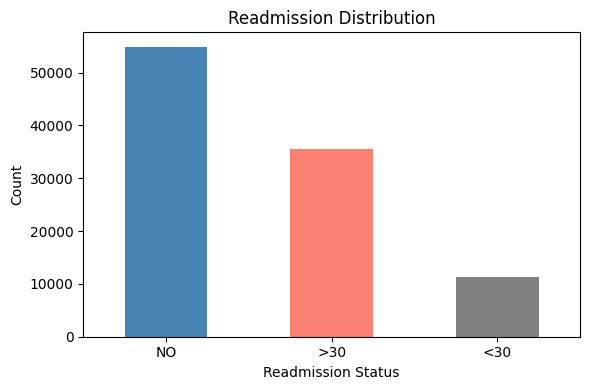

In [10]:
# Readmission distribution chart
plt.figure(figsize=(6, 4))
df['readmitted'].value_counts().plot(kind='bar', color=['steelblue', 'salmon', 'gray'])
plt.title('Readmission Distribution')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('readmission_distribution.png', dpi=150)
plt.show()

## Key Findings

- **101,766 patient records** analyzed from 130 US hospitals (1999-2008)
- **11.2% early readmission rate** (<30 days), reflecting real-world class imbalance
- **Top predictors**: number of lab procedures and medications — consistent with 
  clinical intuition that higher intervention patients carry more readmission risk
- Logistic Regression ROC-AUC: 0.64 | Random Forest ROC-AUC: 0.63
- Class imbalance identified as a key challenge — a next step would be applying 
  SMOTE oversampling to improve recall on high-risk patients